In [1]:
!pip install tensorflow nltk matplotlib -q

In [2]:
# Week 9 Setup — Recurrent Neural Networks and Language Models
import numpy as np
import matplotlib.pyplot as plt
import nltk
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

nltk.download("punkt", quiet=True)

print("Google Colab environment is ready")
print("TensorFlow version:", tf.__version__)

Google Colab environment is ready
TensorFlow version: 2.20.0


In [3]:
# Week 9 Introduction
print("BIT4133: NATURAL LANGUAGE PROCESSING WITH DEEP LEARNING")
print("Week 9: Recurrent Neural Networks and Language Models")
print("=" * 70)

objectives = [
    "Explain sequence data",
    "Describe Recurrent Neural Networks",
    "Differentiate RNNs from traditional neural networks",
    "Understand language models",
    "Build a simple RNN language model",
    "Evaluate the RNN model",
    "Identify limitations of RNNs"
]

for i, objective in enumerate(objectives, 1):
    print(f"{i}. {objective}")

BIT4133: NATURAL LANGUAGE PROCESSING WITH DEEP LEARNING
Week 9: Recurrent Neural Networks and Language Models
1. Explain sequence data
2. Describe Recurrent Neural Networks
3. Differentiate RNNs from traditional neural networks
4. Understand language models
5. Build a simple RNN language model
6. Evaluate the RNN model
7. Identify limitations of RNNs


In [4]:
# Sequence Data Demonstration
sentence = "The court reviewed the evidence before giving judgment."
words = sentence.lower().replace(".", "").split()

print("SEQUENCE DATA OUTPUT")
print("=" * 55)
print("Original sentence:", sentence)
print("Word sequence:", words)
print("The order of words is important because changing the order changes meaning.")

SEQUENCE DATA OUTPUT
Original sentence: The court reviewed the evidence before giving judgment.
Word sequence: ['the', 'court', 'reviewed', 'the', 'evidence', 'before', 'giving', 'judgment']
The order of words is important because changing the order changes meaning.


In [5]:
# Traditional Neural Network vs RNN
comparison = [
    ("Processes inputs independently", "Yes", "No"),
    ("Processes sequences", "No", "Yes"),
    ("Has memory", "No", "Yes"),
    ("Understands context", "Limited", "Better"),
    ("Suitable for text", "Limited", "Yes")
]

print(f"{'Feature':<35} {'Traditional NN':<18} {'RNN'}")
print("-" * 70)

for feature, traditional, rnn in comparison:
    print(f"{feature:<35} {traditional:<18} {rnn}")

Feature                             Traditional NN     RNN
----------------------------------------------------------------------
Processes inputs independently      Yes                No
Processes sequences                 No                 Yes
Has memory                          No                 Yes
Understands context                 Limited            Better
Suitable for text                   Limited            Yes


In [6]:
# RNN Hidden State Demonstration
sentence = "The judge dismissed the appeal"
words = sentence.lower().split()
memory = []

for word in words:
    memory.append(word)
    print("Current word:", word)
    print("Hidden state remembers:", memory)
    print("-" * 40)

Current word: the
Hidden state remembers: ['the']
----------------------------------------
Current word: judge
Hidden state remembers: ['the', 'judge']
----------------------------------------
Current word: dismissed
Hidden state remembers: ['the', 'judge', 'dismissed']
----------------------------------------
Current word: the
Hidden state remembers: ['the', 'judge', 'dismissed', 'the']
----------------------------------------
Current word: appeal
Hidden state remembers: ['the', 'judge', 'dismissed', 'the', 'appeal']
----------------------------------------


In [28]:
# Legal Text Dataset — 105 Sentences

sentences = [
    "the court reviewed the evidence",
    "the judge delivered the judgment",
    "the accused entered a plea",
    "the lawyer presented the argument",
    "the court dismissed the appeal",
    "the witness gave clear evidence",
    "the judge granted the application",
    "the plaintiff filed the case",
    "the defendant denied the claim",
    "the court heard the parties",
    "the lawyer examined the witness",
    "the judge considered the evidence",
    "the court issued the order",
    "the accused requested bail",
    "the appeal challenged the judgment",
    "the court allowed the application",
    "the witness identified the accused",
    "the judge postponed the hearing",
    "the lawyer submitted the documents",
    "the plaintiff won the case",
    "the court rejected the request",
    "the defendant filed an appeal",
    "the judge reviewed the record",
    "the accused denied the charge",
    "the lawyer explained the law",
    "the court examined the facts",
    "the witness attended the hearing",
    "the judge announced the decision",
    "the plaintiff presented the evidence",
    "the defendant answered the claim",
    "the court admitted the evidence",
    "the judge rejected the objection",
    "the accused appeared before court",
    "the lawyer requested more time",
    "the witness described the incident",
    "the plaintiff challenged the decision",
    "the defendant accepted the ruling",
    "the court scheduled the hearing",
    "the judge interpreted the statute",
    "the lawyer cross examined the witness",
    "the accused signed the statement",
    "the court considered the application",
    "the judge recorded the testimony",
    "the plaintiff amended the claim",
    "the defendant submitted a response",
    "the witness confirmed the identity",
    "the court granted the request",
    "the judge dismissed the objection",
    "the lawyer reviewed the contract",
    "the accused challenged the evidence",
    "the plaintiff requested compensation",
    "the defendant denied responsibility",
    "the court examined the documents",
    "the judge delivered the ruling",
    "the witness explained the events",
    "the lawyer filed the submissions",
    "the accused applied for bail",
    "the court postponed the matter",
    "the judge evaluated the testimony",
    "the plaintiff proved the claim",
    "the defendant disputed the facts",
    "the witness answered the questions",
    "the lawyer cited the precedent",
    "the court enforced the judgment",
    "the judge ordered a retrial",
    "the accused appealed the sentence",
    "the plaintiff withdrew the case",
    "the defendant requested dismissal",
    "the court reviewed the submissions",
    "the judge allowed the objection",
    "the witness signed the affidavit",
    "the lawyer prepared the defense",
    "the accused admitted the offence",
    "the court denied the application",
    "the judge considered mitigating factors",
    "the plaintiff filed supporting documents",
    "the defendant challenged jurisdiction",
    "the witness gave sworn testimony",
    "the lawyer requested an adjournment",
    "the court recorded the settlement",
    "the judge approved the agreement",
    "the accused denied the allegations",
    "the plaintiff appealed the ruling",
    "the defendant opposed the application",
    "the witness identified the document",
    "the lawyer summarized the evidence",
    "the court heard final submissions",
    "the judge reserved the judgment",
    "the accused received the sentence",
    "the plaintiff requested legal costs",
    "the defendant accepted the settlement",
    "the witness recalled the conversation",
    "the lawyer questioned the procedure",
    "the court interpreted the contract",
    "the judge cited earlier cases",
    "the accused challenged the charge",
    "the plaintiff proved financial loss",
    "the defendant denied the allegations",
    "the witness verified the signature",
    "the lawyer presented closing arguments",
    "the court delivered the final decision",
    "the judge explained the reasoning",
    "the accused complied with the order",
    "the plaintiff enforced the judgment",
    "the defendant paid the damages"
]

print("LEGAL TEXT DATASET")
print("=" * 55)
print("Dataset size:", len(sentences))
print()

for i, sentence in enumerate(sentences[:15], 1):
    print(f"{i}. {sentence}")

print()
print("Only the first 15 sentences are displayed.")
print("All 105 sentences will be used to train the RNN model.")

LEGAL TEXT DATASET
Dataset size: 105

1. the court reviewed the evidence
2. the judge delivered the judgment
3. the accused entered a plea
4. the lawyer presented the argument
5. the court dismissed the appeal
6. the witness gave clear evidence
7. the judge granted the application
8. the plaintiff filed the case
9. the defendant denied the claim
10. the court heard the parties
11. the lawyer examined the witness
12. the judge considered the evidence
13. the court issued the order
14. the accused requested bail
15. the appeal challenged the judgment

Only the first 15 sentences are displayed.
All 105 sentences will be used to train the RNN model.


In [8]:
# Tokenization and Vocabulary
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

print("WORD INDEX")
print(word_index)
print("Vocabulary size:", vocab_size)

WORD INDEX
{'the': 1, 'court': 2, 'judge': 3, 'evidence': 4, 'accused': 5, 'lawyer': 6, 'witness': 7, 'appeal': 8, 'plaintiff': 9, 'defendant': 10, 'reviewed': 11, 'judgment': 12, 'presented': 13, 'application': 14, 'filed': 15, 'case': 16, 'denied': 17, 'claim': 18, 'examined': 19, 'hearing': 20, 'delivered': 21, 'entered': 22, 'a': 23, 'plea': 24, 'argument': 25, 'dismissed': 26, 'gave': 27, 'clear': 28, 'granted': 29, 'heard': 30, 'parties': 31, 'considered': 32, 'issued': 33, 'order': 34, 'requested': 35, 'bail': 36, 'challenged': 37, 'allowed': 38, 'identified': 39, 'postponed': 40, 'submitted': 41, 'documents': 42, 'won': 43, 'rejected': 44, 'request': 45, 'an': 46, 'record': 47, 'charge': 48, 'explained': 49, 'law': 50, 'facts': 51, 'attended': 52, 'announced': 53, 'decision': 54, 'answered': 55}
Vocabulary size: 56


In [9]:
# Create Input Sequences
input_sequences = []

for sentence in sentences:
    token_list = tokenizer.texts_to_sequences([sentence])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

print("Number of training sequences:", len(input_sequences))
print("First 10 sequences:")
for sequence in input_sequences[:10]:
    print(sequence)

Number of training sequences: 119
First 10 sequences:
[1, 2]
[1, 2, 11]
[1, 2, 11, 1]
[1, 2, 11, 1, 4]
[1, 3]
[1, 3, 21]
[1, 3, 21, 1]
[1, 3, 21, 1, 12]
[1, 5]
[1, 5, 22]


In [10]:
# Pad the Sequences
max_sequence_length = max(len(sequence) for sequence in input_sequences)

padded_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

print("Maximum sequence length:", max_sequence_length)
print(padded_sequences[:10])

Maximum sequence length: 5
[[ 0  0  0  1  2]
 [ 0  0  1  2 11]
 [ 0  1  2 11  1]
 [ 1  2 11  1  4]
 [ 0  0  0  1  3]
 [ 0  0  1  3 21]
 [ 0  1  3 21  1]
 [ 1  3 21  1 12]
 [ 0  0  0  1  5]
 [ 0  0  1  5 22]]


In [11]:
# Separate Predictors and Labels
X = padded_sequences[:, :-1]
labels = padded_sequences[:, -1]
y = to_categorical(labels, num_classes=vocab_size)

print("Predictor shape:", X.shape)
print("Label shape:", y.shape)
print("First predictor:", X[0])
print("First label:", labels[0])

Predictor shape: (119, 4)
Label shape: (119, 56)
First predictor: [0 0 0 1]
First label: 2


In [12]:
# Build the RNN Model
model = Sequential([
    Embedding(vocab_size, 32),
    SimpleRNN(64),
    Dense(vocab_size, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the RNN Model
history = model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("RNN model training completed")

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1261 - loss: 4.0003
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2521 - loss: 3.9342
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2353 - loss: 3.8504
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2437 - loss: 3.7465
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2353 - loss: 3.5799
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2269 - loss: 3.3874 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2269 - loss: 3.2162
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2269 - loss: 3.1046
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2269 - loss: 3.0037
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2353 - loss: 2.8802
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2521 - loss: 2.7765
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3109 - l

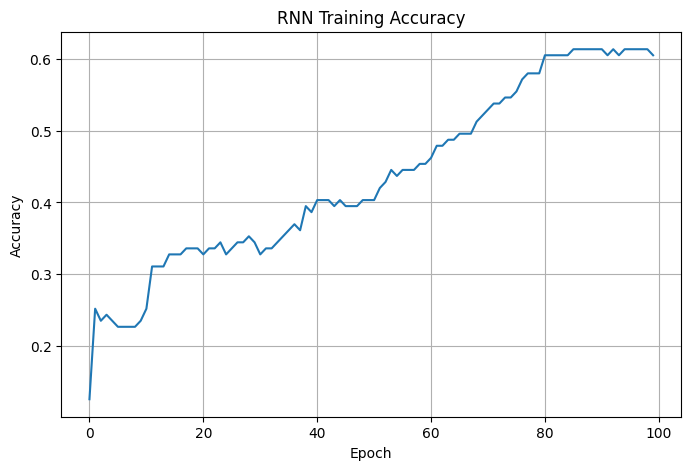

In [14]:
# Training Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"])
plt.title("RNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

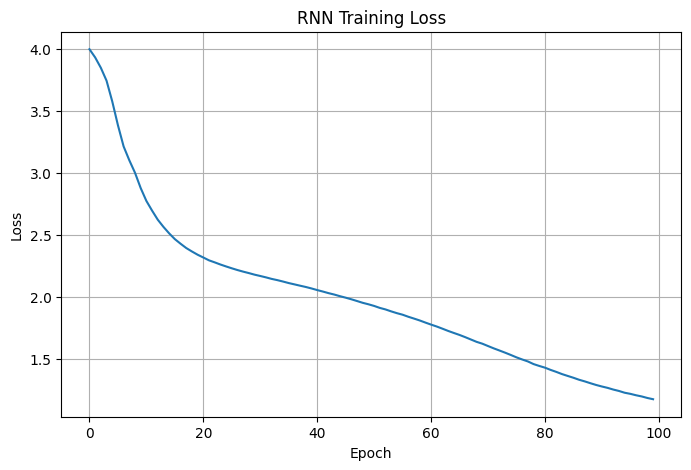

In [15]:
# Training Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"])
plt.title("RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [16]:
# Evaluate the Model
loss, accuracy = model.evaluate(X, y, verbose=0)

print("RNN MODEL EVALUATION")
print("=" * 55)
print("Loss:", round(loss, 4))
print("Accuracy:", round(accuracy, 4))

RNN MODEL EVALUATION
Loss: 1.1664
Accuracy: 0.6134


In [17]:
# Next-Word Prediction Function
def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_length - 1,
        padding="pre"
    )

    probabilities = model.predict(token_list, verbose=0)
    predicted_index = np.argmax(probabilities)

    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            return word

    return "unknown"

print("Prediction function is ready")

Prediction function is ready


In [18]:
# Five RNN Prediction Tests
test_fragments = [
    "the court",
    "the judge",
    "the accused",
    "the lawyer",
    "the witness"
]

print("RNN NEXT-WORD PREDICTIONS")
print("=" * 55)

for fragment in test_fragments:
    print(f"{fragment} -> {predict_next_word(fragment)}")

RNN NEXT-WORD PREDICTIONS
the court -> examined
the judge -> reviewed
the accused -> denied
the lawyer -> presented
the witness -> identified


In [19]:
# Predictive Text Assistant
user_text = input("Enter a sentence fragment: ").lower().strip()

if user_text:
    print("Predicted next word:", predict_next_word(user_text))
else:
    print("No sentence fragment was entered.")

Enter a sentence fragment: how many people does a jury have
Predicted next word: plaintiff


In [20]:
# Ten Prediction Tests
ten_fragments = [
    "the court",
    "the judge",
    "the accused",
    "the lawyer",
    "the witness",
    "the plaintiff",
    "the defendant",
    "the appeal",
    "the court reviewed",
    "the judge delivered"
]

for fragment in ten_fragments:
    print(f"{fragment:<25} -> {predict_next_word(fragment)}")

the court                 -> examined
the judge                 -> reviewed
the accused               -> denied
the lawyer                -> presented
the witness               -> identified
the plaintiff             -> presented
the defendant             -> denied
the appeal                -> challenged
the court reviewed        -> the
the judge delivered       -> the


In [21]:
# Build a Bigram Model
from collections import defaultdict, Counter

bigram_model = defaultdict(Counter)

for sentence in sentences:
    words = sentence.lower().split()

    for i in range(len(words) - 1):
        bigram_model[words[i]][words[i + 1]] += 1

for word in ["court", "judge", "accused", "lawyer", "witness"]:
    print(word, "->", bigram_model[word].most_common(3))

court -> [('reviewed', 1), ('dismissed', 1), ('heard', 1)]
judge -> [('delivered', 1), ('granted', 1), ('considered', 1)]
accused -> [('entered', 1), ('requested', 1), ('denied', 1)]
lawyer -> [('presented', 1), ('examined', 1), ('submitted', 1)]
witness -> [('gave', 1), ('identified', 1), ('attended', 1)]


In [22]:
# Bigram Prediction Function
def bigram_predict(seed_text):
    words = seed_text.lower().split()

    if not words:
        return "unknown"

    last_word = words[-1]

    if last_word in bigram_model and bigram_model[last_word]:
        return bigram_model[last_word].most_common(1)[0][0]

    return "unknown"

print("Bigram prediction function is ready")

Bigram prediction function is ready


In [23]:
# Compare RNN and Bigram Predictions
comparison_fragments = [
    "the court",
    "the judge",
    "the accused",
    "the lawyer",
    "the witness",
    "the plaintiff",
    "the defendant",
    "the appeal"
]

print(f"{'Fragment':<25} {'RNN Prediction':<20} {'Bigram Prediction'}")
print("-" * 70)

for fragment in comparison_fragments:
    print(
        f"{fragment:<25} "
        f"{predict_next_word(fragment):<20} "
        f"{bigram_predict(fragment)}"
    )

Fragment                  RNN Prediction       Bigram Prediction
----------------------------------------------------------------------
the court                 examined             reviewed
the judge                 reviewed             delivered
the accused               denied               entered
the lawyer                presented            presented
the witness               identified           gave
the plaintiff             presented            filed
the defendant             denied               denied
the appeal                challenged           challenged


In [24]:
# Discussion
print("The RNN learns from complete word sequences and uses hidden-state memory.")
print("The bigram model only considers the final word in the input.")
print("The small dataset may cause repetitive or inaccurate predictions.")
print("Accuracy could improve with more data, LSTM, GRU, or Transformer models.")

The RNN learns from complete word sequences and uses hidden-state memory.
The bigram model only considers the final word in the input.
The small dataset may cause repetitive or inaccurate predictions.
Accuracy could improve with more data, LSTM, GRU, or Transformer models.


In [25]:
# Limitations and Improvements
limitations = [
    "Small dataset",
    "Difficulty learning long-term dependencies",
    "Possible overfitting",
    "Sequential training can be slow",
    "Predictions depend on available vocabulary"
]

improvements = [
    "Use at least 100 legal sentences",
    "Replace SimpleRNN with LSTM or GRU",
    "Increase embedding size",
    "Tune epochs and hidden units",
    "Use pre-trained word embeddings",
    "Compare with Transformer models"
]

print("LIMITATIONS")
for item in limitations:
    print("-", item)

print("\nPOSSIBLE IMPROVEMENTS")
for item in improvements:
    print("-", item)

LIMITATIONS
- Small dataset
- Difficulty learning long-term dependencies
- Possible overfitting
- Sequential training can be slow
- Predictions depend on available vocabulary

POSSIBLE IMPROVEMENTS
- Use at least 100 legal sentences
- Replace SimpleRNN with LSTM or GRU
- Increase embedding size
- Tune epochs and hidden units
- Use pre-trained word embeddings
- Compare with Transformer models


In [26]:
# Student Reflection
reflection = (
    "This session helped me understand how Recurrent Neural Networks process sequential "
    "language data using hidden states. I learned how to tokenize text, create and pad "
    "numerical sequences, train an RNN, evaluate accuracy and loss, and predict the next "
    "word. Comparing it with a bigram model showed how neural models use more context."
)

print(reflection)

This session helped me understand how Recurrent Neural Networks process sequential language data using hidden states. I learned how to tokenize text, create and pad numerical sequences, train an RNN, evaluate accuracy and loss, and predict the next word. Comparing it with a bigram model showed how neural models use more context.
